In [1]:
# Dự báo doanh thu theo tháng bằng Linear Regression (kết hợp yếu tố mùa vụ)
# Nội dung notebook:
# - Chuẩn bị dữ liệu và trích xuất đặc trưng mùa vụ
# - Xây dựng Baseline & mô hình Linear Regression
# - Đánh giá và so sánh mô hình
# - Lưu mô hình và dự báo 6 tháng tương lai

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sklearn

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../Data/Superstore Sale Dataset.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# 5.1 Chuẩn bị dữ liệu dự báo
# Tổng hợp Sales theo tháng
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="MS"))["Sales"].sum().reset_index()
monthly_sales.columns = ["MonthStart", "Sales"]

monthly_sales.head()

,MonthStart,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


In [5]:
print("Số dòng dữ liệu theo tháng:", len(monthly_sales))
monthly_sales.tail()

Số dòng dữ liệu theo tháng: 48


,MonthStart,Sales
43,2017-08-01,63120.8880
44,2017-09-01,87866.6520
45,2017-10-01,77776.9232
46,2017-11-01,118447.8250
47,2017-12-01,83829.3188


In [6]:
monthly_sales["TimeIndex"] = np.arange(len(monthly_sales))
monthly_sales.head()

,MonthStart,Sales,TimeIndex
0,2014-01-01,14236.895,0
1,2014-02-01,4519.892,1
2,2014-03-01,55691.009,2
3,2014-04-01,28295.345,3
4,2014-05-01,23648.287,4


In [7]:
# Thêm biến mùa vụ (One-Hot Encoding cho các tháng)
monthly_sales["Month"] = monthly_sales["MonthStart"].dt.month
data_model = pd.get_dummies(monthly_sales, columns=["Month"], drop_first=True)

data_model.head()

,MonthStart,Sales,TimeIndex,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,2014-01-01,14236.895,0,False,False,False,False,False,False,False,False,False,False,False
1,2014-02-01,4519.892,1,True,False,False,False,False,False,False,False,False,False,False
2,2014-03-01,55691.009,2,False,True,False,False,False,False,False,False,False,False,False
3,2014-04-01,28295.345,3,False,False,True,False,False,False,False,False,False,False,False
4,2014-05-01,23648.287,4,False,False,False,True,False,False,False,False,False,False,False


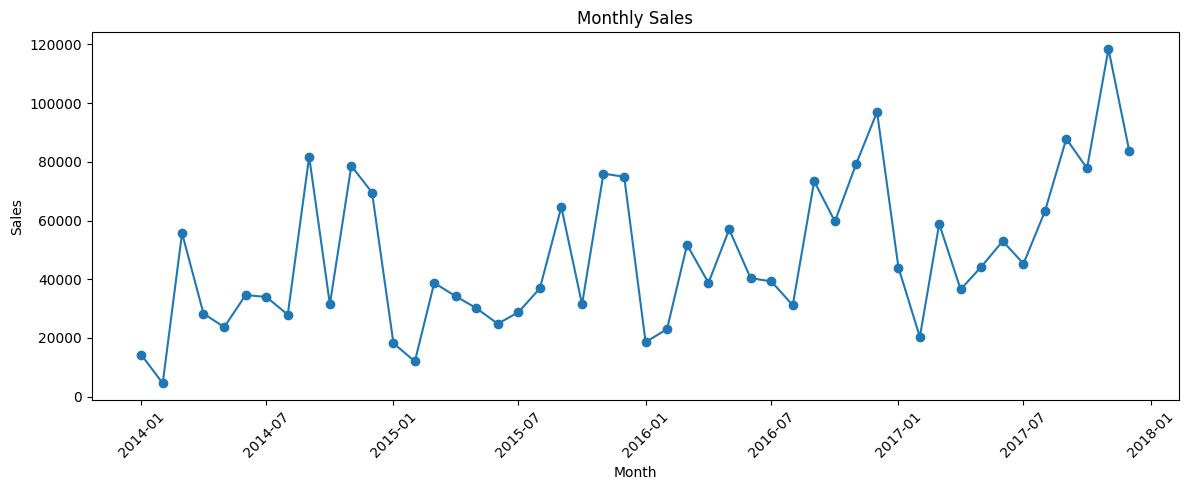

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["MonthStart"], monthly_sales["Sales"], marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# X gồm TimeIndex và các cột đại diện cho từng tháng
feature_cols = [col for col in data_model.columns if col not in ["MonthStart", "Sales"]]
X = data_model[feature_cols]
y = data_model["Sales"]

In [36]:
train_size = int(len(data_model) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 38
Test size: 10


In [37]:
# BASELINE: Dự báo bằng mức doanh thu trung bình của quá khứ
y_pred_baseline = np.full(shape=len(y_test), fill_value=y_train.mean())

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("BASELINE:")
print(f"MAE  = {mae_base:.2f}")
print(f"RMSE = {rmse_base:.2f}")

BASELINE:
MAE  = 25310.85
RMSE = 33851.74


In [38]:
# 5.2 Xây dựng mô hình đánh giá
eval_model = LinearRegression()
eval_model.fit(X_train, y_train)

print("Hệ số chặn (Intercept):", eval_model.intercept_)
print("Hệ số của TimeIndex:", eval_model.coef_[0])

Hệ số chặn (Intercept): 14922.955340000219
Hệ số của TimeIndex: 489.3474199999999


In [39]:
y_pred = eval_model.predict(X_test)

pred_df = pd.DataFrame({
    "MonthStart": monthly_sales["MonthStart"].iloc[train_size:].values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

pred_df.head()

,MonthStart,Actual,Predicted
0,2017-03-01,58872.3528,60455.383413
1,2017-04-01,36521.5361,45491.202247
2,2017-05-01,44261.1102,48666.905247
3,2017-06-01,52981.7257,44989.989280
4,2017-07-01,45264.4160,45735.565080


In [40]:
# 5.3 Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.4f}")

MAE  = 10797.08
RMSE = 14420.71
R²   = 0.6337


In [41]:
comparison_df = pd.DataFrame({
    "Chỉ số": ["MAE", "RMSE"],
    "Baseline (Trung bình)": [mae_base, rmse_base],
    "Mô hình (Linear Regression + Mùa vụ)": [mae, rmse]
})
comparison_df

,Chỉ số,Baseline (Trung bình),Mô hình (Linear Regression + Mùa vụ)
0,MAE,25310.849402,10797.080197
1,RMSE,33851.737586,14420.711685


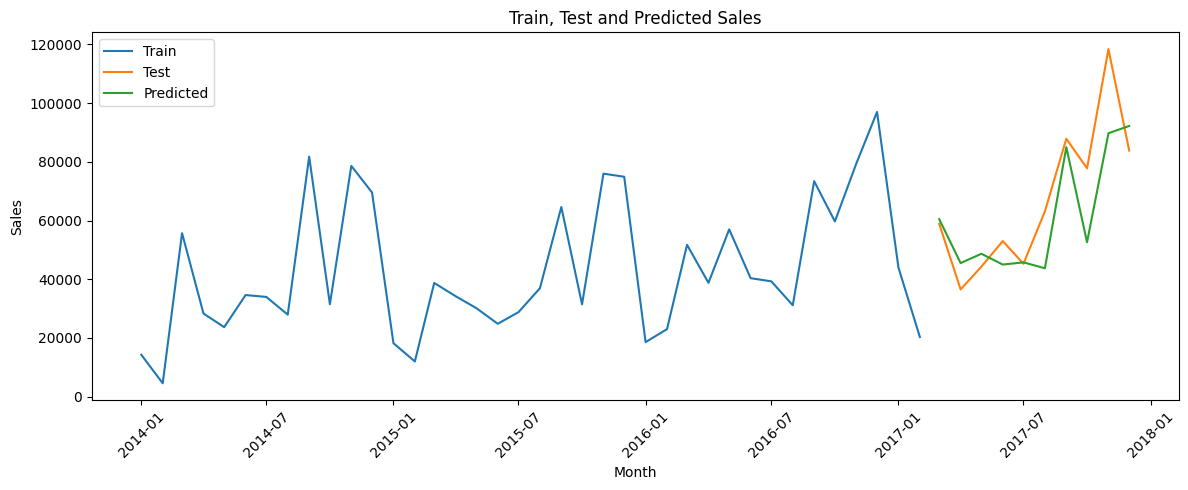

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales["MonthStart"][:train_size], y_train, label="Train")
plt.plot(monthly_sales["MonthStart"][train_size:], y_test, label="Test")
plt.plot(monthly_sales["MonthStart"][train_size:], y_pred, label="Predicted")

plt.title("Train, Test and Predicted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
print("NHẬN XÉT MÔ HÌNH:")
print(f"- MAE = {mae:.2f}")
print(f"- RMSE = {rmse:.2f}")
print(f"- R² = {r2:.4f}")

if rmse < rmse_base:
    print("- Mô hình có sai số RMSE thấp hơn Baseline, đã nắm bắt được xu hướng và mùa vụ tốt hơn mức trung bình.")
else:
    print("- Mô hình cần cải thiện thêm.")

NHẬN XÉT MÔ HÌNH:
- MAE = 10797.08
- RMSE = 14420.71
- R² = 0.6337
- Mô hình có sai số RMSE thấp hơn Baseline, đã nắm bắt được xu hướng và mùa vụ tốt hơn mức trung bình.


In [44]:
# 5.4 Huấn luyện trên toàn bộ 48 tháng trước khi lưu bundle để dự báo tương lai
final_model = LinearRegression()
final_model.fit(X, y)

print("Đã hoàn tất huấn luyện lại trên toàn bộ 48 tháng.")

Đã hoàn tất huấn luyện lại trên toàn bộ 48 tháng.


In [45]:
# 5.5 Lưu mô hình và metadata
model_bundle = {
    "model": final_model,
    "feature_cols": feature_cols,
    "intercept": final_model.intercept_,
    "rmse_backtest": rmse,
    "r2_backtest": r2,
    "sklearn_version": sklearn.__version__
}

joblib.dump(model_bundle, "sales_forecasting_bundle.joblib")
print("Đã lưu bundle model thành công bằng joblib.")

Đã lưu bundle model thành công bằng joblib.


In [46]:
pred_df.to_csv("sales_prediction_results.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file kết quả dự báo.")
pred_df.tail()

Đã lưu file kết quả dự báo.


,MonthStart,Actual,Predicted
5,2017-08-01,63120.8880,43718.729747
6,2017-09-01,87866.6520,85005.435980
7,2017-10-01,77776.9232,52593.025247
8,2017-11-01,118447.8250,89748.753413
9,2017-12-01,83829.3188,92232.399647


In [47]:
# Dự báo 6 tháng tiếp theo (năm 2018)
future_steps = 6
last_index = monthly_sales["TimeIndex"].max()

future_index = np.arange(last_index + 1, last_index + 1 + future_steps)
future_dates = pd.date_range(start=monthly_sales["MonthStart"].max() + pd.offsets.MonthBegin(1), periods=future_steps, freq="MS")

future_input = pd.DataFrame({
    "MonthStart": future_dates,
    "TimeIndex": future_index,
    "Month": future_dates.month
})

future_input = pd.get_dummies(future_input, columns=["Month"], drop_first=True)

for col in feature_cols:
    if col not in future_input.columns:
        future_input[col] = 0

X_future = future_input[feature_cols]

In [48]:
future_pred = final_model.predict(X_future)

future_df = pd.DataFrame({
    "MonthStart": future_dates,
    "PredictedSales": future_pred
})

future_df

,MonthStart,PredictedSales
0,2018-01-01,42180.716406
1,2018-02-01,33387.320356
2,2018-03-01,69700.879706
3,2018-04-01,52890.039656
4,2018-05-01,57206.710431
5,2018-06-01,56629.177331


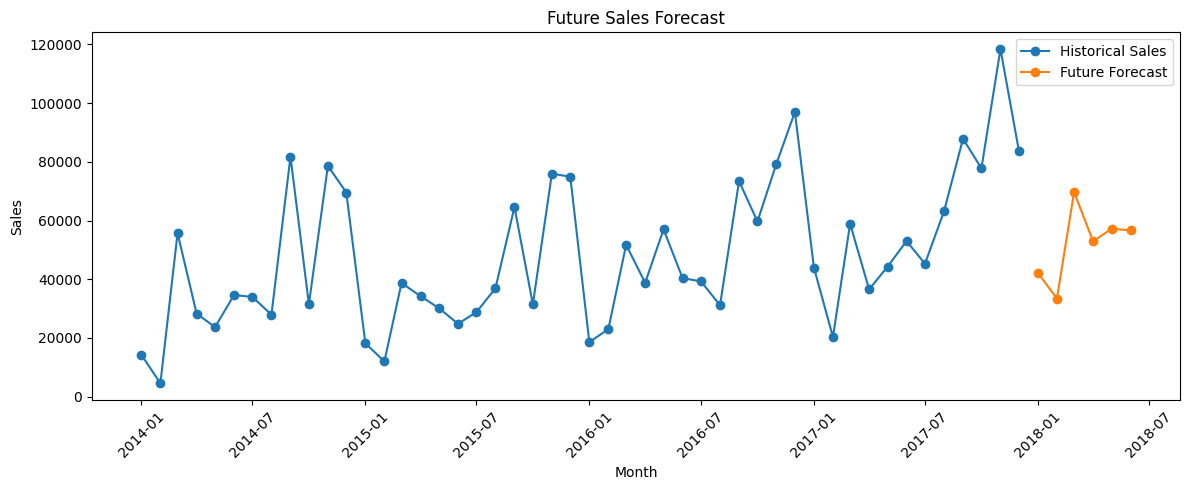

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["MonthStart"], monthly_sales["Sales"], marker="o", label="Historical Sales")
plt.plot(future_df["MonthStart"], future_df["PredictedSales"], marker="o", label="Future Forecast")
plt.title("Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
future_df.to_csv("future_sales_forecast.csv", index=False, encoding="utf-8-sig")
print("Đã lưu file dự báo tương lai.")

Đã lưu file dự báo tương lai.
